In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("/content/continuous dataset.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

target_column = "nat_demand"

features = [
    "T2M_toc","QV2M_toc","TQL_toc","W2M_toc",
    "T2M_san","QV2M_san","TQL_san","W2M_san",
    "T2M_dav","QV2M_dav","TQL_dav","W2M_dav",
    "Holiday_ID","holiday","school"
]

data = df[features + [target_column]]

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

In [ ]:
SEQ_LENGTH = 168  # 1 week

X = []
y = []

target_index = data_scaled.columns.get_loc(target_column)

for i in range(len(data_scaled) - SEQ_LENGTH):
    X.append(data_scaled.iloc[i:i+SEQ_LENGTH].values)
    y.append(data_scaled.iloc[i+SEQ_LENGTH, target_index])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(47880, 168, 16) (47880,)


In [ ]:
split = int(0.8 * len(X))

X_train = torch.tensor(X[:split], dtype=torch.float32).to(device)
X_test = torch.tensor(X[split:], dtype=torch.float32).to(device)

y_train = torch.tensor(y[:split], dtype=torch.float32).to(device)
y_test = torch.tensor(y[split:], dtype=torch.float32).to(device)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model, device=device)
        position = torch.arange(0, max_len, device=device).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, device=device) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [ ]:
class STLFTransformer(nn.Module):
    def __init__(self, input_dim, d_model=128, n_heads=8, num_layers=3, dropout=0.1):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x[:, -1, :]  # Use last timestamp
        out = self.fc(x)
        return out

In [ ]:
iinput_dim = X_train.shape[2]
model = STLFTransformer(input_dim).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Learning rate scheduler (verbose removed for compatibility)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

In [ ]:
epochs = 60             # you can increase later if needed
best_loss = np.inf
patience = 10           # early stopping patience
counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        # Move batch to GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch).squeeze()
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Step the scheduler (ReduceLROnPlateau expects validation or avg loss)
    scheduler.step(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

    # Early stopping
    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        # Save the best model
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 1/60, Loss: 0.020765
Epoch 2/60, Loss: 0.003651
Epoch 3/60, Loss: 0.001872
Epoch 4/60, Loss: 0.001490
Epoch 5/60, Loss: 0.001120
Epoch 6/60, Loss: 0.001018
Epoch 7/60, Loss: 0.000931
Epoch 8/60, Loss: 0.000800
Epoch 9/60, Loss: 0.000790
Epoch 10/60, Loss: 0.000679
Epoch 11/60, Loss: 0.000627
Epoch 12/60, Loss: 0.000595
Epoch 13/60, Loss: 0.000569
Epoch 14/60, Loss: 0.000565
Epoch 15/60, Loss: 0.000538
Epoch 16/60, Loss: 0.000482
Epoch 17/60, Loss: 0.000493
Epoch 18/60, Loss: 0.000453
Epoch 19/60, Loss: 0.000465
Epoch 20/60, Loss: 0.000451
Epoch 21/60, Loss: 0.000429
Epoch 22/60, Loss: 0.000391
Epoch 23/60, Loss: 0.000391
Epoch 24/60, Loss: 0.000419
Epoch 25/60, Loss: 0.000381
Epoch 26/60, Loss: 0.000378
Epoch 27/60, Loss: 0.000330
Epoch 28/60, Loss: 0.000348
Epoch 29/60, Loss: 0.000343
Epoch 30/60, Loss: 0.000318
Epoch 31/60, Loss: 0.000330
Epoch 32/60, Loss: 0.000343
Epoch 33/60, Loss: 0.000308
Epoch 34/60, Loss: 0.000302
Epoch 35/60, Loss: 0.000315
Epoch 36/60, Loss: 0.000326
E

In [ ]:
# Load best saved model
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Move batch to GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        output = model(X_batch).squeeze()
        predictions.extend(output.cpu().numpy())
        actuals.extend(y_batch.cpu().numpy())

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 0.014283397467612424
Test RMSE: 0.019669933968081674


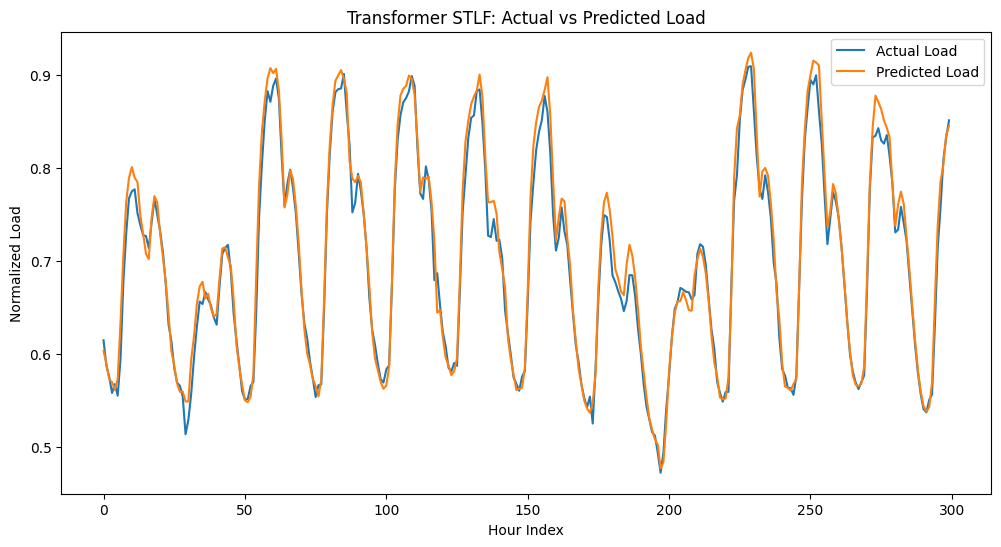

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(actuals[:300], label="Actual Load")      # first 300 points
plt.plot(predictions[:300], label="Predicted Load")
plt.xlabel("Hour Index")
plt.ylabel("Normalized Load")
plt.title("Transformer STLF: Actual vs Predicted Load")
plt.legend()
plt.show()

In [ ]:
epochs = 60
best_loss = np.inf
patience = 10
counter = 0

train_losses = []  # store average loss per epoch

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch).squeeze()
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)  # save loss

    scheduler.step(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 1/60, Loss: 0.000214
Epoch 2/60, Loss: 0.000221
Epoch 3/60, Loss: 0.000209
Epoch 4/60, Loss: 0.000205
Epoch 5/60, Loss: 0.000216
Epoch 6/60, Loss: 0.000214
Epoch 7/60, Loss: 0.000188
Epoch 8/60, Loss: 0.000196
Epoch 9/60, Loss: 0.000209
Epoch 10/60, Loss: 0.000209
Epoch 11/60, Loss: 0.000198
Epoch 12/60, Loss: 0.000190
Epoch 13/60, Loss: 0.000183
Epoch 14/60, Loss: 0.000192
Epoch 15/60, Loss: 0.000192
Epoch 16/60, Loss: 0.000171
Epoch 17/60, Loss: 0.000174
Epoch 18/60, Loss: 0.000178
Epoch 19/60, Loss: 0.000173
Epoch 20/60, Loss: 0.000191
Epoch 21/60, Loss: 0.000184
Epoch 22/60, Loss: 0.000208
Epoch 23/60, Loss: 0.000154
Epoch 24/60, Loss: 0.000148
Epoch 25/60, Loss: 0.000152
Epoch 26/60, Loss: 0.000145
Epoch 27/60, Loss: 0.000150
Epoch 28/60, Loss: 0.000149
Epoch 29/60, Loss: 0.000151
Epoch 30/60, Loss: 0.000148
Epoch 31/60, Loss: 0.000147
Epoch 32/60, Loss: 0.000147
Epoch 33/60, Loss: 0.000133
Epoch 34/60, Loss: 0.000131
Epoch 35/60, Loss: 0.000130
Epoch 36/60, Loss: 0.000130
E

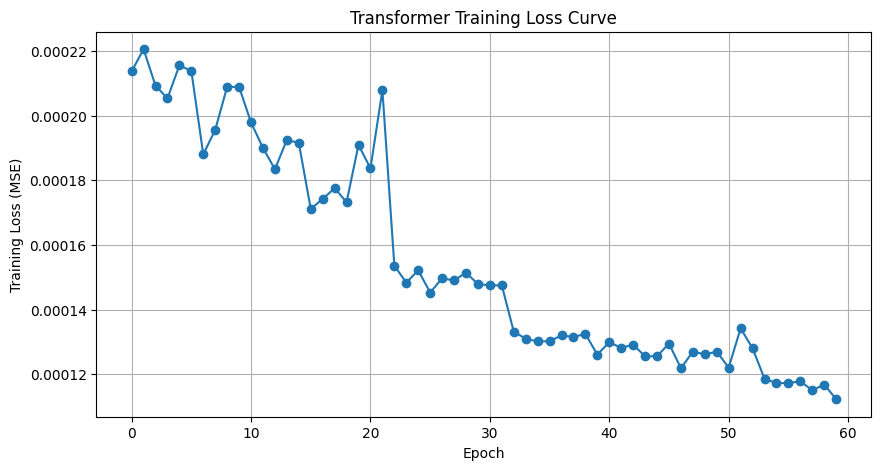

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Transformer Training Loss Curve")
plt.grid(True)
plt.show()

In [ ]:
# Get min and max of target column from original dataframe
target_min = df[target_column].min()
target_max = df[target_column].max()

# Predictions and actuals are normalized 0-1
pred_real = np.array(predictions) * (target_max - target_min) + target_min
actual_real = np.array(actuals) * (target_max - target_min) + target_min

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_mw = mean_absolute_error(actual_real, pred_real)
rmse_mw = np.sqrt(mean_squared_error(actual_real, pred_real))
mape = np.mean(np.abs((actual_real - pred_real) / actual_real)) * 100

print(f"Transformer Performance:")
print(f"MAE  = {mae_mw:.3f} MW")
print(f"RMSE = {rmse_mw:.3f} MW")
print(f"MAPE = {mape:.2f}%")

Transformer Performance:
MAE  = 23.849 MW
RMSE = 32.843 MW
MAPE = 1.99%
